# 🧠 **GRUPO 2 – MLOps | Caso: “Students Performance”**

## 👥 **Integrantes**
- **Claudia Vivas**
- **Evelin Crisel**
- **Alexander Chavez**

---

## 🎯 **Presentación del Caso**

El presente trabajo forma parte del curso de **MLOps**, donde se aborda el ciclo completo de vida de un modelo de Machine Learning utilizando herramientas de versionamiento de datos (**DVC**) y gestión de modelos (**MLflow**).  
El caso práctico elegido es **“Students Performance”**, un dataset educativo que evalúa el rendimiento académico de los estudiantes en función de variables socioeducativas como el nivel educativo de los padres, el tipo de almuerzo, el curso de preparación y otros factores demográficos.

---

## 📘 **Objetivo General**
Implementar un flujo de **MLOps reproducible y trazable**, que permita:
1. Versionar datasets mediante **DVC**.
2. Entrenar, evaluar y registrar modelos de predicción en **MLflow**.
3. Analizar métricas de desempeño, sesgo (fairness) y deriva (drift) entre versiones de datos y modelos.
4. Gestionar la promoción de modelos a entornos de *staging* o *production*.

---

## 🔍 **Descripción del Caso**

El modelo busca **predecir el puntaje de matemáticas (`math_score`)** de los estudiantes, utilizando variables predictoras relacionadas con su entorno familiar y educativo.  
Cada iteración del flujo de trabajo representa una **versión del modelo y del dataset**:

| Versión | Dataset | Descripción del Entrenamiento | Propósito |
|:--------:|:--------|:-----------------------------|:-----------|
| **v1** | `exams_v1.csv` | Modelo base con arquitectura MLP (3 capas, 128 neuronas, lr=1e-3). | Establecer línea base de desempeño. |
| **v2** | `exams_v2.csv` | Mayor capacidad y regularización (2 capas, 256 neuronas, dropout=0.2). | Mejorar generalización y estabilidad. |
| **v3** | `exams_v3.csv` | Ajuste intermedio (3 capas, 192 neuronas, dropout=0.15). | Balance entre sesgo y varianza. |

---

## ⚙️ **Pipeline MLOps**

1. **Preparación y versionamiento de datos** con DVC.  
2. **Entrenamiento, evaluación y logging** de modelos con MLflow Tracking.  
3. **Registro y versionamiento** en MLflow Model Registry.  
4. **Comparación y monitoreo** de métricas (RMSE, MAE, R², fairness, PSI/KS, latencia).  
5. **Promoción de modelos** mediante etapas o alias (`Staging`, `Production`).

---

## 📈 **Resultados Esperados**

- Implementar un sistema reproducible de entrenamiento y registro de modelos.  
- Evaluar cómo cambian las métricas de desempeño entre versiones.  
- Detectar y documentar posibles sesgos o derivas en los datos.  
- Demostrar buenas prácticas de trazabilidad y control de versiones en MLOps.

---

## 🧩 **Herramientas Utilizadas**
- **Python / Jupyter Notebook**
- **scikit-learn**, **TensorFlow / Keras**
- **MLflow** (Tracking + Model Registry)
- **DVC** (Data Version Control)
- **Ngrok** (exposición de MLflow Tracking)
- **Git / GitHub**

---

## 🗺️ Resumen del flujo (Diagrama)
- **Extracción de datos:** Dataset *Kaggle – Students Performance*.
- **Preparación:** limpieza, filtrado y creación de *average score*; codificación de variables y escalado si aplica.
- **Entrenamiento del modelo:** experimentos iterativos (baseline → candidato final).
- **Evaluación y validación:** comparación de modelos y validación; selección del mejor.
- **Tracking y registro:** métricas, parámetros y artefactos con **MLflow**; registro en **Model Registry**.
- **Servicio del modelo:** empaquetado y despliegue del *endpoint* de predicción; consumo desde el **Servicio de predicción**.
- **Versionado de datos:** trazabilidad y reproducibilidad con **DVC**.

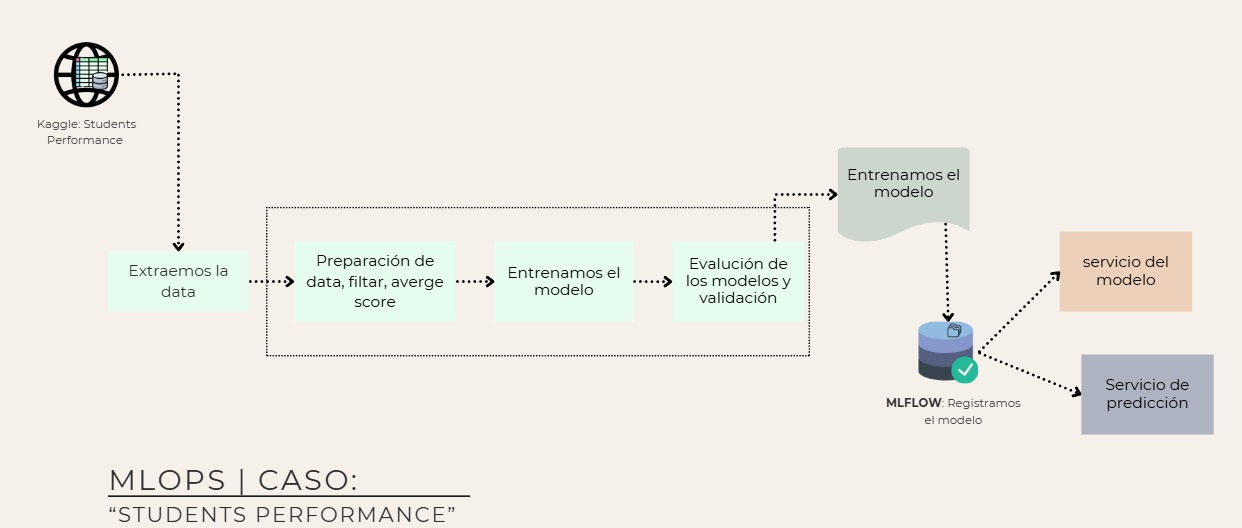
---

> 🧾 *Este cuaderno documenta el flujo completo de versionamiento de datos, entrenamiento, registro y monitoreo del modelo de predicción del rendimiento académico estudiantil.*



# 1. **DVC - Exams (Students Performance)**
Este cuaderno crea un repositorio **Git + DVC**, registra 3 **versiones de datos** sobre tu dataset `exams.csv` y deja todo listo para **push/pull** y **checkout** de versiones.

## Actividades:
● Define el caso de uso y los KPIs esperados por el negocio de
tu modelo

● Define las métricas de monitoreo del rendimiento del
perfomance de tu modelo

● Define 3 versiones de datos en DVC, comenta los cambios
realizados sobre los datos.

---
## 📌 Caso de uso (Business)
**Predicción del desempeño académico** para priorizar tutorías y recursos.
- **Objetivo:** predecir/explicar el rendimiento (p.ej., `avg_score`) y segmentar alumnos (por cohorte o factores socio-educativos) para focalizar intervenciones.
- **Entregable de negocio:** listas de alumnos en riesgo y análisis por grupos (e.g., `race_ethnicity`, `lunch`, `test_preparation_course`).

### 🎯 KPIs de negocio esperados
- **Lift** en la identificación temprana de riesgo (↑ % estudiantes en riesgo correctamente identificados frente a reglas actuales).
- **Reducción** del **tasa de desaprobación** semestral (pp).
- **Cobertura** de intervención (≥ X% de alumnos en riesgo reciben tutoría).
- **Tiempo de respuesta** desde detección → intervención (↓ horas/días).

---
## 📡 Métricas de monitoreo del **performance** del modelo
- **AUC / RMSE / MAE** (según clasificación/regresión).
- **F1 / Recall@k** en la clase "riesgo".
- **Calibración** (Brier score, reliability plot).
- **Deriva** de datos y de predicciones: PSI / KS / distribución de `avg_score` y variables claves.
- **Estabilidad** por cohorte (fairness): gap de error entre grupos (e.g., por `gender`, `race_ethnicity`).
- **SLA** de inferencia: latencia P95 y disponibilidad.

> Estas métricas se registran y se comparan por versión de datos/modelo para detectar degradaciones.



---
## 1.1 **⚙️ Instalación y setup**
Ejecuta esta celda primero (Colab).


In [ ]:

# Instalación
%pip -q install dvc[gs,s3,azure,ssh]==3.* pandas

# Variables del autor (ajusta si quieres)
GIT_USER_EMAIL = "alexanderandrechavezcabana@gmail.com"
GIT_USER_NAME  = "Alexander Andre Chavez Cabana"

import os, shutil, pandas as pd, json, hashlib
from pathlib import Path

# Workspace limpio
WORK = Path("/content/ml_project")
if WORK.exists():
    shutil.rmtree(WORK)
WORK.mkdir(parents=True, exist_ok=True)

%cd /content/ml_project

# Git init + config
!git init -q
!git config user.email "$GIT_USER_EMAIL"
!git config user.name "$GIT_USER_NAME"

# DVC init
!dvc init -q
!git add .dvc .dvcignore
!git commit -m "Initialize DVC" -q

# Remoto local (simulado)
!mkdir -p /content/dvcstore
!dvc remote add -d myremote /content/dvcstore -q
!git add .dvc/config
!git commit -m "Configure DVC remote" -q

print("✅ Repo listo en", WORK)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.5/88.5 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.1/47.1 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 466.2/466.2 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.2/78.2 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.8/438.8 kB 31.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.0/210.0 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.9/119.9 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.9/73.9 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 39.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.


---
## 1.2. **📥 Cargar `exams.csv`**
Sube tu archivo **exams.csv** (el de tu problema) o usa un dataset de ejemplo.


In [ ]:
from google.colab import files
from pathlib import Path
DATA_DIR = Path("/content/ml_project/data")
DATA_DIR.mkdir(parents=True, exist_ok=True)

print("👉 Sube tu exams.csv (o presiona Cancel para auto-crear un ejemplo)")
try:
    up = files.upload()  # Espera subida manual del usuario
    if "exams.csv" in up:
        open(DATA_DIR / "exams.csv", "wb").write(up["exams.csv"])
    else:
        # Si subió con otro nombre, tomar el primero
        k = next(iter(up.keys()))
        open(DATA_DIR / "exams.csv", "wb").write(up[k])
except Exception as e:
    print("No se subió archivo, generando un ejemplo sintético...")
    import pandas as pd, numpy as np
    rng = np.random.default_rng(123)
    n = 200
    df = pd.DataFrame({
        "gender": rng.choice(["female","male"], n),
        "race/ethnicity": rng.choice(["group A","group B","group C","group D","group E"], n),
        "parental level of education": rng.choice(["bachelor's","master's","associate's","some college","high school"], n),
        "lunch": rng.choice(["standard","free/reduced"], n, p=[0.6,0.4]),
        "test preparation course": rng.choice(["none","completed"], n, p=[0.7,0.3]),
        "math score": rng.normal(66, 15, n).clip(0, 100).round(0),
        "reading score": rng.normal(70, 12, n).clip(0, 100).round(0),
        "writing score": rng.normal(68, 14, n).clip(0, 100).round(0),
    })
    df.to_csv(DATA_DIR / "exams.csv", index=False)

# Registra v0 en DVC/Git
!dvc add data/exams.csv -q
!git add data/exams.csv.dvc data/.gitignore
!git commit -m "Add raw data (v0)" -q

print("✅ data/exams.csv listo y trackeado")
!dvc push -q


👉 Sube tu exams.csv (o presiona Cancel para auto-crear un ejemplo)


Saving exams.csv to exams.csv
⠋ Checking graph
✅ data/exams.csv listo y trackeado



---
## 1.3. **🛠️ Versión 1 — Limpieza y métricas básicas**
- Estandariza nombres de columnas (`snake_case`).
- Convierte puntajes a numéricos y **clip [0,100]**.
- Crea `total_score` y `avg_score`.


In [ ]:

import pandas as pd
from pathlib import Path

df = pd.read_csv("data/exams.csv")

# Normaliza nombres
df.columns = [c.strip().lower().replace(" ", "_").replace("/", "_") for c in df.columns]

# Detecta columnas de score
def find(cands):
    for c in cands:
        if c in df.columns: return c
    return None

math_col = find(["math_score","math"])
read_col = find(["reading_score","reading"])
write_col = find(["writing_score","writing"])

for c in [math_col, read_col, write_col]:
    if c:
        df[c] = pd.to_numeric(df[c], errors="coerce").clip(0,100)

score_cols = [c for c in [math_col, read_col, write_col] if c]
if len(score_cols) >= 2:
    df["total_score"] = df[score_cols].sum(axis=1)
    df["avg_score"] = df[score_cols].mean(axis=1)

df.to_csv("data/exams_v1.csv", index=False)

# DVC + Git
!dvc add data/exams_v1.csv -q
!git add data/exams_v1.csv.dvc
!git commit -m "Data v1: limpieza + total_score/avg_score" -q
!dvc push -q

print("✅ v1 creada y enviada al remoto")


⠋ Checking graph
✅ v1 creada y enviada al remoto



---
## 1.4. **🛠️ Versión 2 — **KCIP** (pequeño cambio): filtrar cohorte**
- Si existe `test_preparation_course`, mantener solo **`completed`**.
- Sino, si existe `lunch`, mantener **`standard`**.
- Sino, si existe `race_ethnicity`, mantener **`group_a`**.


In [ ]:

import pandas as pd

df1 = pd.read_csv("data/exams_v1.csv")
cohort_note = ""

def norm_str(s):
    return str(s).strip().lower().replace("/", "_").replace(" ", "_")

df1.columns = [norm_str(c) for c in df1.columns]
for col in ["test_preparation_course","lunch","race_ethnicity"]:
    if col in df1.columns:
        df1[col] = df1[col].astype(str).str.lower().str.strip()

if "test_preparation_course" in df1.columns and "completed" in set(df1["test_preparation_course"]):
    df2 = df1[df1["test_preparation_course"]=="completed"].copy()
    cohort_note = "Filter: test_preparation_course == 'completed'"
elif "lunch" in df1.columns and "standard" in set(df1["lunch"]):
    df2 = df1[df1["lunch"]=="standard"].copy()
    cohort_note = "Filter: lunch == 'standard'"
elif "race_ethnicity" in df1.columns and "group a" in set(df1["race_ethnicity"]):
    df2 = df1[df1["race_ethnicity"]=="group a"].copy()
    cohort_note = "Filter: race_ethnicity == 'group a'"
else:
    df2 = df1.copy()
    cohort_note = "No cohort column found; kept v1 as is."

print("Nota:", cohort_note)
df2.to_csv("data/exams_v2.csv", index=False)

# DVC + Git
!dvc add data/exams_v2.csv -q
!git add data/exams_v2.csv.dvc
!git commit -m "Data v2: KCIP filtro de cohorte" -q
!dvc push -q

print("✅ v2 creada y enviada al remoto")


Nota: Filter: test_preparation_course == 'completed'
⠋ Checking graph
✅ v2 creada y enviada al remoto



---
## 1.5. **🛠️ Versión 3 — **KCIP** (pequeño cambio): eliminar 1 grupo y preparar KPIs**
- Si existe `race_ethnicity`, **elimina** el grupo con menor tamaño (p.ej., `group A`).
- Genera **KPIs** por categoría (promedios de puntajes).


In [ ]:

import pandas as pd

df2 = pd.read_csv("data/exams_v2.csv")

def first_existing(cols, frame):
    for c in cols:
        if c in frame.columns: return c
    return None

group_col = first_existing(
    ["race_ethnicity","parental_level_of_education","lunch","gender","test_preparation_course"], df2
)

# 3a) Eliminar un grupo si es race_ethnicity
if group_col == "race_ethnicity":
    counts = df2[group_col].value_counts(dropna=False)
    if len(counts) > 0:
        smallest = counts.index[-1]
        df3 = df2[df2[group_col] != smallest].copy()
        drop_note = f"Dropped smallest cohort in {group_col}: {smallest}"
    else:
        df3 = df2.copy()
        drop_note = "No cohorts to drop."
else:
    df3 = df2.copy()
    drop_note = "race_ethnicity not present; no cohort dropped."

# 3b) KPIs
score_cols = [c for c in df3.columns if any(k in c for k in ["math","reading","writing"]) and df3[c].dtype != "O"]
kpi = None
if group_col and score_cols:
    agg = {c: "mean" for c in score_cols}
    if "avg_score" in df3.columns:
        agg["avg_score"] = "mean"
    kpi = df3.groupby(group_col).agg(agg).reset_index()
    kpi.to_csv("data/exams_kpis.csv", index=False)

# Guardar v3
df3.to_csv("data/exams_v3.csv", index=False)

print("Nota:", drop_note)
if kpi is not None:
    print("KPIs guardados en data/exams_kpis.csv")

# DVC + Git
!dvc add data/exams_v3.csv -q
!git add data/exams_v3.csv.dvc
!git commit -m "Data v3: KCIP drop de cohort + KPIs" -q
!dvc push -q

# (Opcional) versionar KPIs también
!dvc add data/exams_kpis.csv -q
!git add data/exams_kpis.csv.dvc
!git commit -m "KPIs por cohorte" -q
!dvc push -q

print("✅ v3 creada y enviada al remoto")


Nota: Dropped smallest cohort in race_ethnicity: group a
KPIs guardados en data/exams_kpis.csv
⠋ Checking graph
⠋ Checking graph
✅ v3 creada y enviada al remoto



---
## 1.6. **🔁 Movernos entre versiones**
Usa `git checkout` sobre el `.dvc` y luego `dvc checkout` para sincronizar el **working tree**.


In [ ]:

print("Histórico:")
!git --no-pager log --oneline -n 10

print("\nContenido de data/ (working tree):")
!ls -lh data | sed -n '1,120p'

print("\nEjemplo: volver al commit anterior (solo demostración, comenta si no quieres).")
# !git checkout HEAD~1 data/exams_v3.csv.dvc
# !dvc checkout
# !git checkout -


Histórico:
9955265 (HEAD -> master) KPIs por cohorte
6b7b5fe Data v3: KCIP drop de cohort + KPIs
244cc26 Data v2: KCIP filtro de cohorte
09452cf Data v1: limpieza + total_score/avg_score
76ef72e Add raw data (v0)
a61f79e Configure DVC remote
3a43410 Initialize DVC

Contenido de data/ (working tree):
total 220K
-rw-r--r-- 1 root root 71K Oct 25 10:40 exams.csv
-rw-r--r-- 1 root root  90 Oct 25 10:40 exams.csv.dvc
-rw-r--r-- 1 root root 383 Oct 25 10:40 exams_kpis.csv
-rw-r--r-- 1 root root  93 Oct 25 10:40 exams_kpis.csv.dvc
-rw-r--r-- 1 root root 72K Oct 25 10:40 exams_v1.csv
-rw-r--r-- 1 root root  93 Oct 25 10:40 exams_v1.csv.dvc
-rw-r--r-- 1 root root 26K Oct 25 10:40 exams_v2.csv
-rw-r--r-- 1 root root  93 Oct 25 10:40 exams_v2.csv.dvc
-rw-r--r-- 1 root root 24K Oct 25 10:40 exams_v3.csv
-rw-r--r-- 1 root root  93 Oct 25 10:40 exams_v3.csv.dvc

Ejemplo: volver al commit anterior (solo demostración, comenta si no quieres).



---
## 1.7. **☁️ Pull/restore desde el remoto**
Simula pérdida de cache/archivos locales y restaura con `dvc pull`.


In [ ]:

# Simulación de pérdida local (¡Cuidado! solo demo)
!rm -rf .dvc/cache
!rm -f data/exams_v3.csv
!dvc pull
!ls -lh data | sed -n '1,120p'
print("Descomenta el bloque para probar pull/restore.")


Fetching
!
  0% |          |0/? [00:00<?,    ?files/s]
                                           
!
  0% |          |0/? [00:00<?,    ?files/s]
                                           
Fetching from local:   0% 0/5 [00:00<?, ?file/s]
Fetching from local:   0% 0/5 [00:00<?, ?file/s{'info': ''}]
Fetching
Building workspace index          |5.00 [00:00,  115entry/s]
Comparing indexes          |7.00 [00:00, 1.81kentry/s]
Applying changes          |1.00 [00:00,   860file/s]
A       data/exams_v3.csv
5 files fetched and 1 file added
total 220K
-rw-r--r-- 1 root root 71K Oct 25 10:40 exams.csv
-rw-r--r-- 1 root root  90 Oct 25 10:40 exams.csv.dvc
-rw-r--r-- 1 root root 383 Oct 25 10:40 exams_kpis.csv
-rw-r--r-- 1 root root  93 Oct 25 10:40 exams_kpis.csv.dvc
-rw-r--r-- 1 root root 72K Oct 25 10:40 exams_v1.csv
-rw-r--r-- 1 root root  93 Oct 25 10:40 exams_v1.csv.dvc
-rw-r--r-- 1 root root 26K Oct 25 10:40 exams_v2.csv
-rw-r--r-- 1 root root  93 Oct 25 10:40 exams_v2.csv.dvc
-rw-r--r-- 1 ro


---
## 1.8. **✅ Resumen de versiones**
- **v0**: `data/exams.csv` — datos crudos (raw).
- **v1**: `data/exams_v1.csv` — limpieza + `total_score` / `avg_score`.
- **v2**: `data/exams_v2.csv` — **KCIP** filtro de cohorte.
- **v3**: `data/exams_v3.csv` — **KCIP** drop de cohorte + `data/exams_kpis.csv`.

Cada CSV está **trackeado con DVC** y tiene su `.dvc` correspondiente. Usa `git log`, `git checkout` y `dvc checkout` para navegar entre versiones.


# 2. **Versionamiento de Modelos con MLflow**

Requerimientos:

- AUTH_TOKEN de [Ngrok](https://ngrok.com/)

## **2.1. Instalación de MLflow**

In [ ]:
%pip -q install mlflow pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 61.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 77.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 66.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 752.6/752.6 kB 47.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.4/203.4 kB 16.7 MB/s eta 0:00:00


## **2.1. Inicio del servidor de MLflow Tracking**

In [ ]:
# Librerías

import os, signal, subprocess, time, shutil
from pathlib import Path

## **2.2. Lectura del Token de NGROK**

> Agregar bloque entrecomillado


In [ ]:
# ------------------ NGROK: leer token desde secretos de Colab ----------------
try:
    from google.colab import userdata  # solo existe en Colab
    NGROK_AUTH_TOKEN = userdata.get("NGROK_AUTH_TOKEN")
except Exception:
    NGROK_AUTH_TOKEN = None

if not NGROK_AUTH_TOKEN:
    raise RuntimeError(
        "No se encontró el secreto 'NGROK_AUTH_TOKEN'. "
        "En Colab ve a: Entorno de ejecución > Configurar secretos > agrega NGROK_AUTH_TOKEN."
    )

from pyngrok import ngrok

ngrok.set_auth_token(NGROK_AUTH_TOKEN)

# Cierra túneles previos si los hubiera
try:
    for t in ngrok.get_tunnels():
        ngrok.disconnect(t.public_url)
except Exception:
    pass

ERROR:pyngrok.process.ngrok:t=2025-10-25T10:41:15+0000 lvl=eror msg="failed to reconnect session" obj=tunnels.session err="authentication failed: Your account is limited to 1 simultaneous ngrok agent sessions.\nRun multiple endpoints at the same time from a single agent by defining them in your agent configuration file and running `ngrok start --all`.\nRead more about the agent configuration file: https://ngrok.com/docs/agent/config/ \nYou can view your current agent sessions in the dashboard: https://dashboard.ngrok.com/agents. Upgrade to a paid plan to remove this limit:\nhttps://dashboard.ngrok.com/billing/choose-a-plan\r\n\r\nERR_NGROK_108\r\n"
ERROR:pyngrok.process.ngrok:t=2025-10-25T10:41:15+0000 lvl=eror msg="session closing" obj=tunnels.session err="authentication failed: Your account is limited to 1 simultaneous ngrok agent sessions.\nRun multiple endpoints at the same time from a single agent by defining them in your agent configuration file and running `ngrok start --all`.\n

## **2.3. Definimos variables de entorno**

In [ ]:
# ------------------ Rutas para backend y artifacts ------------------
BASE_DIR = Path("/content")
BACKEND_URI = f"sqlite:///{BASE_DIR/'mlflow.db'}"          # SQLite para tracking
ARTIFACTS_DIR = BASE_DIR / "mlruns"                        # carpeta local
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACTS_URI = f"file://{ARTIFACTS_DIR}"                  # URI file://

PORT = 5000  # MLflow por defecto
HOST = "0.0.0.0"

## **2.4. Eliminamos procesos antiguos de MLflow**

In [ ]:
# ------------------ Mata procesos MLflow viejos (si quedaron) ------------------
def kill_process_on_port(port: int):
    try:
        out = subprocess.check_output(["bash", "-lc", f"lsof -ti:{port} || true"]).decode().strip()
        if out:
            for pid in out.splitlines():
                try:
                    os.kill(int(pid), signal.SIGTERM)
                except Exception:
                    pass
    except Exception:
        pass

kill_process_on_port(PORT)

## **2.5. Inicialización del servicio de MLflow Tracking**

In [ ]:
# ------------------ Arranca MLflow Tracking Server ------------------
# --serve-artifacts permite que el propio server entregue artifacts (MLflow >= 2.2)
mlflow_cmd = [
    "bash", "-lc",
    (
        "mlflow server "
        f"--backend-store-uri '{BACKEND_URI}' "
        f"--host {HOST} --port {PORT} "
        f"--serve-artifacts --artifacts-destination '{ARTIFACTS_URI}'"
    )
]

mlflow_proc = subprocess.Popen(
    mlflow_cmd,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1
)

# Lee un poco de salida para confirmar que arrancó
start_deadline = time.time() + 20  # da unos segundos para levantar
ready = False
buffer = []
while time.time() < start_deadline:
    line = mlflow_proc.stdout.readline()
    if not line:
        time.sleep(0.2)
        continue
    buffer.append(line)
    # Heurística simple de "ready"
    if "Gunicorn" in line or "Running on" in line or "Beginning gunicorn" in line:
        ready = True
        break

print("Log inicial de MLflow:")
print("".join(buffer) if buffer else "(sin logs iniciales)")

if mlflow_proc.poll() is not None and mlflow_proc.returncode not in (None, 0):
    raise RuntimeError("El proceso de MLflow terminó inesperadamente. Revisa el log de arriba.")

Log inicial de MLflow:
2025/10/25 10:41:32 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2025/10/25 10:41:32 INFO mlflow.store.db.utils: Updating database tables
2025-10-25 10:41:32 INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
2025-10-25 10:41:32 INFO  [alembic.runtime.migration] Will assume non-transactional DDL.
2025-10-25 10:41:32 INFO  [alembic.runtime.migration] Running upgrade  -> 451aebb31d03, add metric step
2025-10-25 10:41:32 INFO  [alembic.runtime.migration] Running upgrade 451aebb31d03 -> 90e64c465722, migrate user column to tags
2025-10-25 10:41:32 INFO  [alembic.runtime.migration] Running upgrade 90e64c465722 -> 181f10493468, allow nulls for metric values
2025-10-25 10:41:32 INFO  [alembic.runtime.migration] Running upgrade 181f10493468 -> df50e92ffc5e, Add Experiment Tags Table
2025-10-25 10:41:32 INFO  [alembic.runtime.migration] Running upgrade df50e92ffc5e -> 7ac759974ad8, Update run tags with larger limit
2025-10-25 10:41:32 INF

## **2.6. Exponemos el API sobre un tunel con NGROK**

In [ ]:
# ------------------ Abre túnel ngrok ------------------
public_url = ngrok.connect(
    PORT,
    proto="http",
    bind_tls=True,           # sirve también por https
    host_header="rewrite"    # <- clave: reescribe el Host a localhost:<PORT>
).public_url
print(f"\n MLflow Tracking UI (ngrok): {public_url}")
print(f"   Backend store URI: {BACKEND_URI}")
print(f"   Artifacts URI:     {ARTIFACTS_URI}\n")

# Exporta variable de entorno para que mlflow lo use desde Python
os.environ["MLFLOW_TRACKING_URI"] = public_url
print(f"MLFLOW_TRACKING_URI seteado a: {os.environ['MLFLOW_TRACKING_URI']}")

# Utilidad para parar todo de forma manual si lo necesitas
def stop_mlflow_and_ngrok():
    try:
        for t in ngrok.get_tunnels():
            ngrok.disconnect(t.public_url)
    except Exception:
        pass
    if mlflow_proc and mlflow_proc.poll() is None:
        mlflow_proc.terminate()
        try:
            mlflow_proc.wait(timeout=5)
        except subprocess.TimeoutExpired:
            mlflow_proc.kill()
    print("MLflow y ngrok detenidos.")


 MLflow Tracking UI (ngrok): https://1a4fa63a5e78.ngrok-free.app
   Backend store URI: sqlite:////content/mlflow.db
   Artifacts URI:     file:///content/mlruns

MLFLOW_TRACKING_URI seteado a: https://1a4fa63a5e78.ngrok-free.app


### **Seteamos la URI del servicio en la variable de entorno de MLflow Tracking Server**

Para poder tener el contexto de los experimentos desde el servicio

In [ ]:
# Pequeña prueba opcional: setear el tracking URI en el cliente Python
try:
    import mlflow
    mlflow.set_tracking_uri(os.environ["MLFLOW_TRACKING_URI"])
    print("mlflow.set_tracking_uri configurado correctamente.")
except Exception as e:
    print("Advertencia al configurar mlflow.set_tracking_uri:", e)
# ============================================================================

mlflow.set_tracking_uri configurado correctamente.


## **2.7. Registraremos el modelo y metadata a MLflow**

En este siguiente paso, usaremos el modelo que entrenamos, los hiperparámetros que especificamos para el ajuste del modelo y las métricas de pérdida que se calcularon al evaluar el desempeño del modelo en los datos de prueba para registrarlos en MLflow.

Los pasos que seguiremos son:

* Iniciar un contexto de ejecución (run) de MLflow para comenzar una nueva ejecución en la que registraremos el modelo y sus metadatos.

* Registrar (log) los parámetros del modelo y las métricas de rendimiento.

* Etiquetar la ejecución para facilitar su recuperación.

* Registrar el modelo en el MLflow Model Registry mientras se registra (guarda) el modelo.

### **2.7.1. **Entrenamiento v1 (baseline) — `exams_v1.csv`****
En esta primera versión entrenamos el modelo base y registramos todo en MLflow.

**Objetivo**: establecer una línea base de performance con los datos `exams_v1.csv` (target: `math_score`).

**Modelo**: MLP (Keras) con:
- `units=128`, `layers=3`, `dropout=0.10`, `lr=1e-3`, `epochs=70`, `batch_size=32`.

**Tracking (MLflow)**:
- Parámetros del modelo y versión de datos.
- Métricas core: `RMSE`, `MAE`, `R2`.
- Métricas “riesgo” (clasificación derivada con umbral 60): `AUC`, `F1`, `Recall@10%`, `Brier`.
- Fairness: `fairness_mae_gap` por `gender` y `race_ethnicity`.
- Deriva: `PSI`/`KS` (target y variables clave).
- SLA: `latency_p50_ms`, `latency_p95_ms`.
- Artefactos: curva de pérdida (`loss_curve.png`), dispersión `y vs ŷ` (`y_vs_pred.png`).
- El run queda nombrado como `exams_v1.csv` y se guarda el modelo en `artifact_path="model"`.


In [ ]:
# --- v1 baseline (exams_v1.csv) ---
# Objetivo: establecer línea base de performance con datos v1 (target: math_score).
# Modelo: MLP Keras (units=128, layers=3, dropout=0.10, lr=1e-3, epochs=70, batch=32).
# MLflow: log de params/metrics/artefactos + fairness, deriva PSI/KS y SLA (p50/p95).
# Run name = "exams_v1.csv"; modelo guardado en artifact_path="model".

import os, io, time, math, numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, roc_auc_score, f1_score
from scipy.stats import ks_2samp
import mlflow, mlflow.keras
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout

# ---------- Config ----------
EXPERIMENT_NAME = "student_performance"
DATA_DIR = Path("data")                     # donde viven tus v1/v2/v3
DATA_VERSION = "exams_v1.csv"              # <-- cambia a v2/v3 si quieres
TARGET = "math_score"                       # snake_case en tus versiones
RISK_THRESHOLD = 60                         # para métricas tipo clasificación opcionales

# Ya debes tener MLFLOW_TRACKING_URI seteado (por la celda de ngrok)
mlflow.set_tracking_uri(os.environ["MLFLOW_TRACKING_URI"])
mlflow.set_experiment(EXPERIMENT_NAME)

# ---------- Utils ----------
def rmse(y_true, y_pred): return float(np.sqrt(mean_squared_error(y_true, y_pred)))
def mae(y_true, y_pred):  return float(mean_absolute_error(y_true, y_pred))
def r2(y_true, y_pred):   return float(r2_score(y_true, y_pred))

def brier_score(y_true_bin, p_pred): return float(np.mean((p_pred - y_true_bin)**2))
def recall_at_k(y_true_bin, score, k=0.1):
    n = len(score); top = max(1, int(math.ceil(k*n)))
    idx = np.argsort(score)[::-1][:top]
    tp = y_true_bin[idx].sum(); fn = y_true_bin.sum() - tp
    return float(tp / (tp+fn) if (tp+fn)>0 else 0.0)

def ks_stat(a,b):
    a,b = pd.Series(a).dropna(), pd.Series(b).dropna()
    if len(a)==0 or len(b)==0: return np.nan
    return float(ks_2samp(a,b).statistic)

def psi(expected, actual, bins=10):
    expected, actual = pd.Series(expected).dropna(), pd.Series(actual).dropna()
    if len(expected)==0 or len(actual)==0: return np.nan
    q = np.linspace(0,1,bins+1)
    cuts = np.unique(expected.quantile(q).values)
    if len(cuts)<3: cuts = np.linspace(expected.min(), expected.max(), bins+1)
    e = np.histogram(expected, bins=cuts)[0]; a = np.histogram(actual, bins=cuts)[0]
    ep, ap = e/(e.sum()+1e-12), a/(a.sum()+1e-12)
    return float(np.sum((ap-ep)*np.log((ap+1e-12)/(ep+1e-12))))

def fairness_mae_gap(df, y_true, y_pred, group_col):
    if group_col not in df.columns: return np.nan, pd.DataFrame()
    tmp = pd.DataFrame({group_col: df[group_col].astype(str), "abs_err": np.abs(y_true-y_pred)})
    tab = tmp.groupby(group_col)["abs_err"].mean().reset_index().rename(columns={"abs_err":"mae"})
    if tab.empty: return np.nan, tab
    return float(tab["mae"].max()-tab["mae"].min()), tab

def fig_to_png_bytes():
    buf = io.BytesIO(); plt.savefig(buf, format="png", bbox_inches="tight"); plt.close(); buf.seek(0); return buf.getvalue()

def load_and_prepare(csv_path):
    df = pd.read_csv(csv_path)
    # renombres compatibles (si tu archivo viniera con nombres originales)
    df = df.rename(columns={
        'race/ethnicity': 'race_ethnicity',
        'gender': 'gender',
        'parental level of education': 'parental_level_of_education'
    })
    # encode categóricas
    for c in ['gender','race_ethnicity','parental_level_of_education','lunch','test_preparation_course']:
        if c in df.columns:
            df[c] = LabelEncoder().fit_transform(df[c].astype(str))
    if TARGET not in df.columns:
        raise ValueError(f"Falta columna objetivo: {TARGET}")
    y = df[TARGET].astype(float).values
    X = df.drop(columns=[TARGET], errors="ignore").values
    scaler = StandardScaler()
    Xtr, Xte, ytr, yte, dtr, dte = train_test_split(X, y, df, test_size=0.2, random_state=42)
    return scaler.fit_transform(Xtr), scaler.transform(Xte), ytr, yte, dtr.reset_index(drop=True), dte.reset_index(drop=True)

def build_model(input_dim, units=128, layers=3, lr=1e-3, dropout=0.1):
    model = Sequential()
    model.add(tf.keras.Input(shape=(input_dim,)))   # ✅ evita el warning de Keras
    model.add(Dense(units, activation='relu'))
    if dropout>0: model.add(Dropout(dropout))
    u = units
    for _ in range(layers-1):
        u = max(16, u//2)
        model.add(Dense(u, activation='relu'))
        if dropout>0: model.add(Dropout(dropout))
    model.add(Dense(1))
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr), loss='mse', metrics=['mae'])
    return model

def timed_predictions(model, X, batch=128, repeats=5):
    times=[]
    for _ in range(repeats):
        t0=time.perf_counter(); _=model.predict(X, batch_size=batch, verbose=0); t1=time.perf_counter()
        times.append((t1-t0)*1000.0)
    return float(np.percentile(times,50)), float(np.percentile(times,95))

def train_and_log(data_version, params, epochs=60, batch_size=32, enable_risk=True, risk_threshold=RISK_THRESHOLD):
    Xtr,Xte,ytr,yte,dftr,dfte = load_and_prepare(DATA_DIR/data_version)
    with mlflow.start_run(run_name=f"{data_version}") as run:
        mlflow.log_param("data_version", data_version)
        mlflow.log_params(params | {"epochs":epochs,"batch_size":batch_size})

        model = build_model(Xtr.shape[1], **params)
        hist = model.fit(Xtr, ytr, validation_data=(Xte,yte), epochs=epochs, batch_size=batch_size, verbose=0)

        # Curvas de pérdida
        plt.figure(figsize=(8,3))
        plt.plot(hist.history["loss"],label="train_mse")
        plt.plot(hist.history["val_loss"],label="val_mse")
        plt.legend(); plt.xlabel("epoch"); plt.ylabel("MSE"); plt.title("Loss")
        path_loss="loss_curve.png"; open(path_loss,"wb").write(fig_to_png_bytes()); mlflow.log_artifact(path_loss)

        # Predicción y métricas core
        yhat = model.predict(Xte, verbose=0).ravel()
        _rmse, _mae, _r2 = rmse(yte,yhat), mae(yte,yhat), r2(yte,yhat)
        mlflow.log_metrics({"rmse":_rmse,"mae":_mae,"r2":_r2})

        # Scatter y vs ŷ
        plt.figure(figsize=(5,5)); plt.scatter(yte,yhat,alpha=0.6)
        plt.xlabel("y_real"); plt.ylabel("y_pred"); plt.title("y vs ŷ")
        path_sc="y_vs_pred.png"; open(path_sc,"wb").write(fig_to_png_bytes()); mlflow.log_artifact(path_sc)

        # SLA: latencia
        p50,p95 = timed_predictions(model,Xte,batch=128,repeats=5)
        mlflow.log_metrics({"latency_p50_ms":p50,"latency_p95_ms":p95})

        # Fairness (gap MAE)
        gap_g, tab_g = fairness_mae_gap(dfte, yte, yhat, "gender")
        gap_r, tab_r = fairness_mae_gap(dfte, yte, yhat, "race_ethnicity")
        mlflow.log_metrics({"fairness_mae_gap_gender":gap_g, "fairness_mae_gap_race":gap_r})
        if not tab_g.empty: tab_g.to_csv("mae_by_gender.csv", index=False); mlflow.log_artifact("mae_by_gender.csv")
        if not tab_r.empty: tab_r.to_csv("mae_by_race.csv", index=False);  mlflow.log_artifact("mae_by_race.csv")

        # Deriva: PSI/KS entre splits
        mlflow.log_metrics({
            "psi_target_train_test": psi(ytr, yte),
            "ks_target_train_test":  ks_stat(ytr, yte)
        })
        for col in ["gender","race_ethnicity","lunch"]:
            if col in dftr.columns:
                mlflow.log_metric(f"psi_{col}_train_test", psi(dftr[col], dfte[col]))

        # Métricas de “riesgo” opcionales (clasificación derivada)
        if enable_risk:
            y_bin = (yte < risk_threshold).astype(int)
            y_min, y_max = ytr.min(), ytr.max()
            p_pred = (yhat - y_min) / max(1e-9,(y_max-y_min))  # 0..1 (alto score = menos riesgo)
            p_pred = np.clip(1 - p_pred, 0, 1)                # prob. de riesgo
            try:
                auc = roc_auc_score(y_bin, p_pred)
            except ValueError:
                auc = np.nan
            f1    = f1_score(y_bin, (p_pred>=0.5).astype(int))
            rec10 = recall_at_k(y_bin, p_pred, k=0.10)
            brier = brier_score(y_bin, p_pred)
            mlflow.log_metrics({
                "auc_risk": float(auc),
                "f1_risk": float(f1),
                "recall_at_10pct_risk": float(rec10),  # ✅ nombre válido
                "brier_risk": float(brier)
            })

        # Log del modelo
        mlflow.keras.log_model(model, artifact_path="model")

        print(f"[{data_version}] RMSE={_rmse:.3f} MAE={_mae:.3f} R2={_r2:.3f} P95={p95:.1f}ms GAP(gender)={gap_g:.3f} GAP(race)={gap_r:.3f}")
        return {"rmse":_rmse,"mae":_mae,"r2":_r2,"latency_p95_ms":p95}

# --------- Entrena una versión (ajusta DATA_VERSION arriba) ----------
params = dict(units=128, layers=3, lr=1e-3, dropout=0.1)
res = train_and_log(DATA_VERSION, params, epochs=70, batch_size=32, enable_risk=True)
res

2025/10/25 10:43:50 INFO mlflow.tracking.fluent: Experiment with name 'student_performance' does not exist. Creating a new experiment.
2025/10/25 10:44:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/10/25 10:44:13 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.
2025/10/25 10:44:27 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


[exams_v1.csv] RMSE=1.372 MAE=1.058 R2=0.991 P95=90.6ms GAP(gender)=0.417 GAP(race)=0.607
🏃 View run exams_v1.csv at: https://1a4fa63a5e78.ngrok-free.app/#/experiments/1/runs/b1a72031f7ee450db5c6009e1db94095
🧪 View experiment at: https://1a4fa63a5e78.ngrok-free.app/#/experiments/1


{'rmse': 1.3719585027040495,
 'mae': 1.0579094123840331,
 'r2': 0.9914738318486767,
 'latency_p95_ms': 90.56136820003076}

#### ***2.7.1.1.Registraremos el modelo 1 y metadata a MLflow***

En este siguiente paso, usaremos el modelo que entrenamos, los hiperparámetros que especificamos para el ajuste del modelo y las métricas de pérdida que se calcularon al evaluar el desempeño del modelo en los datos de prueba para registrarlos en MLflow.

Los pasos que seguiremos son:

* Iniciar un contexto de ejecución (run) de MLflow para comenzar una nueva ejecución en la que registraremos el modelo y sus metadatos.

* Registrar (log) los parámetros del modelo y las métricas de rendimiento.

* Etiquetar la ejecución para facilitar su recuperación.

* Registrar el modelo en el MLflow Model Registry mientras se registra (guarda) el modelo.

In [ ]:
from mlflow.tracking import MlflowClient
from mlflow import register_model

client = MlflowClient()

# 1) Consigue el run_id del run activo (si estás dentro del with start_run)
#    o del último run del experimento.
active = mlflow.active_run()
if active is not None:
    run_id = active.info.run_id
else:
    exp = mlflow.get_experiment_by_name("student_performance")
    runs = client.search_runs(experiment_ids=[exp.experiment_id], order_by=["attributes.start_time DESC"], max_results=1)
    run_id = runs[0].info.run_id

print("run_id:", run_id)

# 2) arma el model_uri correcto:
#    - Si logueaste con artifact_path="model"  → usa ".../model"
#    - Si logueaste con name="student_regressor" → usa ".../student_regressor"
artifact_name = "model"  # o "student_regressor" según lo que usaste al loguear
model_uri = f"runs:/{run_id}/{artifact_name}"

# 3) registra en el Model Registry
registered_name = "student-regressor-registry"
mv = register_model(model_uri=model_uri, name=registered_name)
print("Registered model version:", mv.version)

# 4) (opcional) promover etapa + tags de versión
client.transition_model_version_stage(name=registered_name, version=mv.version, stage="Staging", archive_existing_versions=False)
client.set_model_version_tag(registered_name, mv.version, "data_version", DATA_VERSION)
client.set_model_version_tag(registered_name, mv.version, "notes", f"Baseline {DATA_VERSION}")

run_id: b1a72031f7ee450db5c6009e1db94095


Successfully registered model 'student-regressor-registry'.
2025/10/25 10:44:30 WARNING mlflow.tracking._model_registry.fluent: Run with id b1a72031f7ee450db5c6009e1db94095 has no artifacts at artifact path 'model', registering model based on models:/m-aa7ad3c9a0c64767ab2eaad26a6ae3ae instead
2025/10/25 10:44:31 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: student-regressor-registry, version 1
Created version '1' of model 'student-regressor-registry'.


Registered model version: 1


/tmp/ipython-input-521576356.py:30: FutureWarning: ``mlflow.tracking.client.MlflowClient.transition_model_version_stage`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  client.transition_model_version_stage(name=registered_name, version=mv.version, stage="Staging", archive_existing_versions=False)


### ***2.7.2. ***Entrenamiento v2 — `exams_v2.csv`******
Segunda versión con cambios de arquitectura e hiperparámetros para explorar más capacidad con mayor regularización.

**Cambios vs v1**:
- Datos: `exams_v2.csv`.
- Modelo: `units=256`, `layers=2`, `dropout=0.20`, `lr=5e-4`, `epochs=60`, `batch_size=32`.
  (Más neuronas por capa, menos profundidad, más regularización; LR más bajo).

**Tracking (MLflow)**:
- Misma instrumentación que v1: core, riesgo (umbral 60), fairness, deriva, SLA.
- Artefactos de curvas y dispersión.
- Run nombrado `exams_v2.csv` y modelo en `artifact_path="model"`.
- Esta corrida se registrará como **nueva versión** en el **mismo Registered Model**.


In [ ]:
# --- v2 (exams_v2.csv) ---
# Cambios: units=256, layers=2, dropout=0.20, lr=5e-4, epochs=60, batch=32.
# Intención: ↑ capacidad por capa + ↑ regularización; comparar vs v1.
# MLflow: mismas métricas/artefactos; run name="exams_v2.csv"; artifact_path="model".
# Luego: registrar como nueva versión en "student-regressor-registry".

import os, io, time, math, numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, roc_auc_score, f1_score
from scipy.stats import ks_2samp
import mlflow, mlflow.keras
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout

# ---------- Config ----------
EXPERIMENT_NAME = "student_performance"
DATA_DIR = Path("data")                     # donde viven tus v1/v2/v3
DATA_VERSION = "exams_v2.csv"              # <-- cambia a v2/v3 si quieres
TARGET = "math_score"                       # snake_case en tus versiones
RISK_THRESHOLD = 60                         # para métricas tipo clasificación opcionales

# Ya debes tener MLFLOW_TRACKING_URI seteado (por la celda de ngrok)
mlflow.set_tracking_uri(os.environ["MLFLOW_TRACKING_URI"])
mlflow.set_experiment(EXPERIMENT_NAME)

# ---------- Utils ----------
def rmse(y_true, y_pred): return float(np.sqrt(mean_squared_error(y_true, y_pred)))
def mae(y_true, y_pred):  return float(mean_absolute_error(y_true, y_pred))
def r2(y_true, y_pred):   return float(r2_score(y_true, y_pred))

def brier_score(y_true_bin, p_pred): return float(np.mean((p_pred - y_true_bin)**2))
def recall_at_k(y_true_bin, score, k=0.1):
    n = len(score); top = max(1, int(math.ceil(k*n)))
    idx = np.argsort(score)[::-1][:top]
    tp = y_true_bin[idx].sum(); fn = y_true_bin.sum() - tp
    return float(tp / (tp+fn) if (tp+fn)>0 else 0.0)

def ks_stat(a,b):
    a,b = pd.Series(a).dropna(), pd.Series(b).dropna()
    if len(a)==0 or len(b)==0: return np.nan
    return float(ks_2samp(a,b).statistic)

def psi(expected, actual, bins=10):
    expected, actual = pd.Series(expected).dropna(), pd.Series(actual).dropna()
    if len(expected)==0 or len(actual)==0: return np.nan
    q = np.linspace(0,1,bins+1)
    cuts = np.unique(expected.quantile(q).values)
    if len(cuts)<3: cuts = np.linspace(expected.min(), expected.max(), bins+1)
    e = np.histogram(expected, bins=cuts)[0]; a = np.histogram(actual, bins=cuts)[0]
    ep, ap = e/(e.sum()+1e-12), a/(a.sum()+1e-12)
    return float(np.sum((ap-ep)*np.log((ap+1e-12)/(ep+1e-12))))

def fairness_mae_gap(df, y_true, y_pred, group_col):
    if group_col not in df.columns: return np.nan, pd.DataFrame()
    tmp = pd.DataFrame({group_col: df[group_col].astype(str), "abs_err": np.abs(y_true-y_pred)})
    tab = tmp.groupby(group_col)["abs_err"].mean().reset_index().rename(columns={"abs_err":"mae"})
    if tab.empty: return np.nan, tab
    return float(tab["mae"].max()-tab["mae"].min()), tab

def fig_to_png_bytes():
    buf = io.BytesIO(); plt.savefig(buf, format="png", bbox_inches="tight"); plt.close(); buf.seek(0); return buf.getvalue()

def load_and_prepare(csv_path):
    df = pd.read_csv(csv_path)
    # renombres compatibles (si tu archivo viniera con nombres originales)
    df = df.rename(columns={
        'race/ethnicity': 'race_ethnicity',
        'gender': 'gender',
        'parental level of education': 'parental_level_of_education'
    })
    # encode categóricas
    for c in ['gender','race_ethnicity','parental_level_of_education','lunch','test_preparation_course']:
        if c in df.columns:
            df[c] = LabelEncoder().fit_transform(df[c].astype(str))
    if TARGET not in df.columns:
        raise ValueError(f"Falta columna objetivo: {TARGET}")
    y = df[TARGET].astype(float).values
    X = df.drop(columns=[TARGET], errors="ignore").values
    scaler = StandardScaler()
    Xtr, Xte, ytr, yte, dtr, dte = train_test_split(X, y, df, test_size=0.2, random_state=42)
    return scaler.fit_transform(Xtr), scaler.transform(Xte), ytr, yte, dtr.reset_index(drop=True), dte.reset_index(drop=True)

def build_model(input_dim, units=128, layers=3, lr=1e-3, dropout=0.1):
    model = Sequential()
    model.add(tf.keras.Input(shape=(input_dim,)))   # ✅ evita el warning de Keras
    model.add(Dense(units, activation='relu'))
    if dropout>0: model.add(Dropout(dropout))
    u = units
    for _ in range(layers-1):
        u = max(16, u//2)
        model.add(Dense(u, activation='relu'))
        if dropout>0: model.add(Dropout(dropout))
    model.add(Dense(1))
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr), loss='mse', metrics=['mae'])
    return model

def timed_predictions(model, X, batch=128, repeats=5):
    times=[]
    for _ in range(repeats):
        t0=time.perf_counter(); _=model.predict(X, batch_size=batch, verbose=0); t1=time.perf_counter()
        times.append((t1-t0)*1000.0)
    return float(np.percentile(times,50)), float(np.percentile(times,95))

def train_and_log(data_version, params, epochs=60, batch_size=32, enable_risk=True, risk_threshold=RISK_THRESHOLD):
    Xtr,Xte,ytr,yte,dftr,dfte = load_and_prepare(DATA_DIR/data_version)
    with mlflow.start_run(run_name=f"{data_version}") as run:
        mlflow.log_param("data_version", data_version)
        mlflow.log_params(params | {"epochs":epochs,"batch_size":batch_size})

        model = build_model(Xtr.shape[1], **params)
        hist = model.fit(Xtr, ytr, validation_data=(Xte,yte), epochs=epochs, batch_size=batch_size, verbose=0)

        # Curvas de pérdida
        plt.figure(figsize=(8,3))
        plt.plot(hist.history["loss"],label="train_mse")
        plt.plot(hist.history["val_loss"],label="val_mse")
        plt.legend(); plt.xlabel("epoch"); plt.ylabel("MSE"); plt.title("Loss")
        path_loss="loss_curve.png"; open(path_loss,"wb").write(fig_to_png_bytes()); mlflow.log_artifact(path_loss)

        # Predicción y métricas core
        yhat = model.predict(Xte, verbose=0).ravel()
        _rmse, _mae, _r2 = rmse(yte,yhat), mae(yte,yhat), r2(yte,yhat)
        mlflow.log_metrics({"rmse":_rmse,"mae":_mae,"r2":_r2})

        # Scatter y vs ŷ
        plt.figure(figsize=(5,5)); plt.scatter(yte,yhat,alpha=0.6)
        plt.xlabel("y_real"); plt.ylabel("y_pred"); plt.title("y vs ŷ")
        path_sc="y_vs_pred.png"; open(path_sc,"wb").write(fig_to_png_bytes()); mlflow.log_artifact(path_sc)

        # SLA: latencia
        p50,p95 = timed_predictions(model,Xte,batch=128,repeats=5)
        mlflow.log_metrics({"latency_p50_ms":p50,"latency_p95_ms":p95})

        # Fairness (gap MAE)
        gap_g, tab_g = fairness_mae_gap(dfte, yte, yhat, "gender")
        gap_r, tab_r = fairness_mae_gap(dfte, yte, yhat, "race_ethnicity")
        mlflow.log_metrics({"fairness_mae_gap_gender":gap_g, "fairness_mae_gap_race":gap_r})
        if not tab_g.empty: tab_g.to_csv("mae_by_gender.csv", index=False); mlflow.log_artifact("mae_by_gender.csv")
        if not tab_r.empty: tab_r.to_csv("mae_by_race.csv", index=False);  mlflow.log_artifact("mae_by_race.csv")

        # Deriva: PSI/KS entre splits
        mlflow.log_metrics({
            "psi_target_train_test": psi(ytr, yte),
            "ks_target_train_test":  ks_stat(ytr, yte)
        })
        for col in ["gender","race_ethnicity","lunch"]:
            if col in dftr.columns:
                mlflow.log_metric(f"psi_{col}_train_test", psi(dftr[col], dfte[col]))

        # Métricas de “riesgo” opcionales (clasificación derivada)
        if enable_risk:
            y_bin = (yte < risk_threshold).astype(int)
            y_min, y_max = ytr.min(), ytr.max()
            p_pred = (yhat - y_min) / max(1e-9,(y_max-y_min))  # 0..1 (alto score = menos riesgo)
            p_pred = np.clip(1 - p_pred, 0, 1)                # prob. de riesgo
            try:
                auc = roc_auc_score(y_bin, p_pred)
            except ValueError:
                auc = np.nan
            f1    = f1_score(y_bin, (p_pred>=0.5).astype(int))
            rec10 = recall_at_k(y_bin, p_pred, k=0.10)
            brier = brier_score(y_bin, p_pred)
            mlflow.log_metrics({
                "auc_risk": float(auc),
                "f1_risk": float(f1),
                "recall_at_10pct_risk": float(rec10),  # ✅ nombre válido
                "brier_risk": float(brier)
            })

        # Log del modelo
        mlflow.keras.log_model(model, artifact_path="model")

        print(f"[{data_version}] RMSE={_rmse:.3f} MAE={_mae:.3f} R2={_r2:.3f} P95={p95:.1f}ms GAP(gender)={gap_g:.3f} GAP(race)={gap_r:.3f}")
        return {"rmse":_rmse,"mae":_mae,"r2":_r2,"latency_p95_ms":p95}

# --------- Entrena una versión (ajusta DATA_VERSION arriba) ----------
params_v2 = dict(units=256, layers=2, lr=5e-4, dropout=0.2)
res_v2 = train_and_log(
    DATA_VERSION,
    params_v2,
    epochs=60,
    batch_size=32,
    enable_risk=True
)
res_v2

2025/10/25 10:45:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/10/25 10:45:16 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.
2025/10/25 10:45:26 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


[exams_v2.csv] RMSE=6.436 MAE=5.247 R2=0.789 P95=76.6ms GAP(gender)=0.107 GAP(race)=4.705
🏃 View run exams_v2.csv at: https://1a4fa63a5e78.ngrok-free.app/#/experiments/1/runs/6f3607d176584bbfb9166d2c255885ab
🧪 View experiment at: https://1a4fa63a5e78.ngrok-free.app/#/experiments/1


{'rmse': 6.43611643332455,
 'mae': 5.247041342914969,
 'r2': 0.7890362921510796,
 'latency_p95_ms': 76.5637690000176}

#### ***2.7.2.1.Registraremos el modelo 2 y metadata a MLflow***

En este siguiente paso, usaremos el modelo que entrenamos, los hiperparámetros que especificamos para el ajuste del modelo y las métricas de pérdida que se calcularon al evaluar el desempeño del modelo en los datos de prueba para registrarlos en MLflow.

Los pasos que seguiremos son:

* Iniciar un contexto de ejecución (run) de MLflow para comenzar una nueva ejecución en la que registraremos el modelo y sus metadatos.

* Registrar (log) los parámetros del modelo y las métricas de rendimiento.

* Etiquetar la ejecución para facilitar su recuperación.

* Registrar el modelo en el MLflow Model Registry mientras se registra (guarda) el modelo.

In [ ]:
from mlflow.tracking import MlflowClient
from mlflow import register_model
import json

REGISTERED_NAME = "student-regressor-registry"  # 👈 mismo nombre

client = MlflowClient()
exp = mlflow.get_experiment_by_name(EXPERIMENT_NAME)

# Busca el run más reciente con run_name = nombre del CSV que acabas de entrenar
runs = client.search_runs(
    [exp.experiment_id],
    filter_string=f"tags.mlflow.runName = '{DATA_VERSION}'",
    order_by=["attributes.start_time DESC"],
    max_results=1,
)
assert runs, f"No se encontró run para {DATA_VERSION}"
run_id = runs[0].info.run_id
print("run_id v2:", run_id)

# URI del modelo dentro del run (artifact_path="model")
model_uri = f"runs:/{run_id}/model"

# Registra como nueva versión en el mismo Registered Model
mv = register_model(model_uri=model_uri, name=REGISTERED_NAME)
print(f"✅ Nueva versión registrada: {REGISTERED_NAME} v{mv.version}")

# Tags útiles en la versión del modelo
client.set_model_version_tag(REGISTERED_NAME, mv.version, "data_version", DATA_VERSION)
client.set_model_version_tag(REGISTERED_NAME, mv.version, "params", json.dumps(params_v2))

# (Opcional) usa alias 'staging' (MLflow ≥2.9) o, si no existe, fallback a stages
try:
    client.set_registered_model_alias(REGISTERED_NAME, "staging", mv.version)
    print("🔖 Alias 'staging' -> versión", mv.version)
except Exception:
    # Fallback a stages (si tu versión de MLflow aún usa stages)
    client.transition_model_version_stage(
        name=REGISTERED_NAME,
        version=mv.version,
        stage="Staging",
        archive_existing_versions=False,
    )
    print("🟩 Stage 'Staging' asignado a la versión", mv.version)


run_id v2: 6f3607d176584bbfb9166d2c255885ab


Registered model 'student-regressor-registry' already exists. Creating a new version of this model...
2025/10/25 10:45:29 WARNING mlflow.tracking._model_registry.fluent: Run with id 6f3607d176584bbfb9166d2c255885ab has no artifacts at artifact path 'model', registering model based on models:/m-5b45d2c342084e17804998d81094e11e instead
2025/10/25 10:45:29 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: student-regressor-registry, version 2
Created version '2' of model 'student-regressor-registry'.


✅ Nueva versión registrada: student-regressor-registry v2
🔖 Alias 'staging' -> versión 2


### **2.7.3. Entrenamiento v3 — `exams_v3.csv`**
Tercera versión buscando balance entre profundidad y regularización.

**Cambios vs v2**:
- Datos: `exams_v3.csv`.
- Modelo: `units=192`, `layers=3`, `dropout=0.15`, `lr=7.5e-4`, `epochs=60`, `batch_size=32`.
  (Profundidad como v1 pero con más unidades que v1 y dropout intermedio).

**Tracking (MLflow)**:
- Igual que v1/v2: core, riesgo (umbral 60), fairness, deriva, SLA.
- Artefactos de curvas y dispersión.
- Run nombrado `exams_v3.csv` y modelo en `artifact_path="model"`.
- Registrar como nueva versión en el **mismo** Registered Model y etiquetar con `data_version` y `params`.

In [ ]:
# --- v3 (exams_v3.csv) ---
# Cambios: units=192, layers=3, dropout=0.15, lr=7.5e-4, epochs=60, batch=32.
# Intención: balance sesgo-varianza; comparar contra v1 y v2.
# MLflow: mismas métricas/artefactos; run name="exams_v3.csv"; artifact_path="model".
# Registrar como nueva versión en "student-regressor-registry" con tags (data_version, params).

import os, io, time, math, numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, roc_auc_score, f1_score
from scipy.stats import ks_2samp
import mlflow, mlflow.keras
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout

# ---------- Config ----------
EXPERIMENT_NAME = "student_performance"
DATA_DIR = Path("data")                     # donde viven tus v1/v2/v3
DATA_VERSION = "exams_v3.csv"              # <-- cambia a v2/v3 si quieres
TARGET = "math_score"                       # snake_case en tus versiones
RISK_THRESHOLD = 60                         # para métricas tipo clasificación opcionales

# Ya debes tener MLFLOW_TRACKING_URI seteado (por la celda de ngrok)
mlflow.set_tracking_uri(os.environ["MLFLOW_TRACKING_URI"])
mlflow.set_experiment(EXPERIMENT_NAME)

# ---------- Utils ----------
def rmse(y_true, y_pred): return float(np.sqrt(mean_squared_error(y_true, y_pred)))
def mae(y_true, y_pred):  return float(mean_absolute_error(y_true, y_pred))
def r2(y_true, y_pred):   return float(r2_score(y_true, y_pred))

def brier_score(y_true_bin, p_pred): return float(np.mean((p_pred - y_true_bin)**2))
def recall_at_k(y_true_bin, score, k=0.1):
    n = len(score); top = max(1, int(math.ceil(k*n)))
    idx = np.argsort(score)[::-1][:top]
    tp = y_true_bin[idx].sum(); fn = y_true_bin.sum() - tp
    return float(tp / (tp+fn) if (tp+fn)>0 else 0.0)

def ks_stat(a,b):
    a,b = pd.Series(a).dropna(), pd.Series(b).dropna()
    if len(a)==0 or len(b)==0: return np.nan
    return float(ks_2samp(a,b).statistic)

def psi(expected, actual, bins=10):
    expected, actual = pd.Series(expected).dropna(), pd.Series(actual).dropna()
    if len(expected)==0 or len(actual)==0: return np.nan
    q = np.linspace(0,1,bins+1)
    cuts = np.unique(expected.quantile(q).values)
    if len(cuts)<3: cuts = np.linspace(expected.min(), expected.max(), bins+1)
    e = np.histogram(expected, bins=cuts)[0]; a = np.histogram(actual, bins=cuts)[0]
    ep, ap = e/(e.sum()+1e-12), a/(a.sum()+1e-12)
    return float(np.sum((ap-ep)*np.log((ap+1e-12)/(ep+1e-12))))

def fairness_mae_gap(df, y_true, y_pred, group_col):
    if group_col not in df.columns: return np.nan, pd.DataFrame()
    tmp = pd.DataFrame({group_col: df[group_col].astype(str), "abs_err": np.abs(y_true-y_pred)})
    tab = tmp.groupby(group_col)["abs_err"].mean().reset_index().rename(columns={"abs_err":"mae"})
    if tab.empty: return np.nan, tab
    return float(tab["mae"].max()-tab["mae"].min()), tab

def fig_to_png_bytes():
    buf = io.BytesIO(); plt.savefig(buf, format="png", bbox_inches="tight"); plt.close(); buf.seek(0); return buf.getvalue()

def load_and_prepare(csv_path):
    df = pd.read_csv(csv_path)
    # renombres compatibles (si tu archivo viniera con nombres originales)
    df = df.rename(columns={
        'race/ethnicity': 'race_ethnicity',
        'gender': 'gender',
        'parental level of education': 'parental_level_of_education'
    })
    # encode categóricas
    for c in ['gender','race_ethnicity','parental_level_of_education','lunch','test_preparation_course']:
        if c in df.columns:
            df[c] = LabelEncoder().fit_transform(df[c].astype(str))
    if TARGET not in df.columns:
        raise ValueError(f"Falta columna objetivo: {TARGET}")
    y = df[TARGET].astype(float).values
    X = df.drop(columns=[TARGET], errors="ignore").values
    scaler = StandardScaler()
    Xtr, Xte, ytr, yte, dtr, dte = train_test_split(X, y, df, test_size=0.2, random_state=42)
    return scaler.fit_transform(Xtr), scaler.transform(Xte), ytr, yte, dtr.reset_index(drop=True), dte.reset_index(drop=True)

def build_model(input_dim, units=128, layers=3, lr=1e-3, dropout=0.1):
    model = Sequential()
    model.add(tf.keras.Input(shape=(input_dim,)))   # ✅ evita el warning de Keras
    model.add(Dense(units, activation='relu'))
    if dropout>0: model.add(Dropout(dropout))
    u = units
    for _ in range(layers-1):
        u = max(16, u//2)
        model.add(Dense(u, activation='relu'))
        if dropout>0: model.add(Dropout(dropout))
    model.add(Dense(1))
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr), loss='mse', metrics=['mae'])
    return model

def timed_predictions(model, X, batch=128, repeats=5):
    times=[]
    for _ in range(repeats):
        t0=time.perf_counter(); _=model.predict(X, batch_size=batch, verbose=0); t1=time.perf_counter()
        times.append((t1-t0)*1000.0)
    return float(np.percentile(times,50)), float(np.percentile(times,95))

def train_and_log(data_version, params, epochs=60, batch_size=32, enable_risk=True, risk_threshold=RISK_THRESHOLD):
    Xtr,Xte,ytr,yte,dftr,dfte = load_and_prepare(DATA_DIR/data_version)
    with mlflow.start_run(run_name=f"{data_version}") as run:
        mlflow.log_param("data_version", data_version)
        mlflow.log_params(params | {"epochs":epochs,"batch_size":batch_size})

        model = build_model(Xtr.shape[1], **params)
        hist = model.fit(Xtr, ytr, validation_data=(Xte,yte), epochs=epochs, batch_size=batch_size, verbose=0)

        # Curvas de pérdida
        plt.figure(figsize=(8,3))
        plt.plot(hist.history["loss"],label="train_mse")
        plt.plot(hist.history["val_loss"],label="val_mse")
        plt.legend(); plt.xlabel("epoch"); plt.ylabel("MSE"); plt.title("Loss")
        path_loss="loss_curve.png"; open(path_loss,"wb").write(fig_to_png_bytes()); mlflow.log_artifact(path_loss)

        # Predicción y métricas core
        yhat = model.predict(Xte, verbose=0).ravel()
        _rmse, _mae, _r2 = rmse(yte,yhat), mae(yte,yhat), r2(yte,yhat)
        mlflow.log_metrics({"rmse":_rmse,"mae":_mae,"r2":_r2})

        # Scatter y vs ŷ
        plt.figure(figsize=(5,5)); plt.scatter(yte,yhat,alpha=0.6)
        plt.xlabel("y_real"); plt.ylabel("y_pred"); plt.title("y vs ŷ")
        path_sc="y_vs_pred.png"; open(path_sc,"wb").write(fig_to_png_bytes()); mlflow.log_artifact(path_sc)

        # SLA: latencia
        p50,p95 = timed_predictions(model,Xte,batch=128,repeats=5)
        mlflow.log_metrics({"latency_p50_ms":p50,"latency_p95_ms":p95})

        # Fairness (gap MAE)
        gap_g, tab_g = fairness_mae_gap(dfte, yte, yhat, "gender")
        gap_r, tab_r = fairness_mae_gap(dfte, yte, yhat, "race_ethnicity")
        mlflow.log_metrics({"fairness_mae_gap_gender":gap_g, "fairness_mae_gap_race":gap_r})
        if not tab_g.empty: tab_g.to_csv("mae_by_gender.csv", index=False); mlflow.log_artifact("mae_by_gender.csv")
        if not tab_r.empty: tab_r.to_csv("mae_by_race.csv", index=False);  mlflow.log_artifact("mae_by_race.csv")

        # Deriva: PSI/KS entre splits
        mlflow.log_metrics({
            "psi_target_train_test": psi(ytr, yte),
            "ks_target_train_test":  ks_stat(ytr, yte)
        })
        for col in ["gender","race_ethnicity","lunch"]:
            if col in dftr.columns:
                mlflow.log_metric(f"psi_{col}_train_test", psi(dftr[col], dfte[col]))

        # Métricas de “riesgo” opcionales (clasificación derivada)
        if enable_risk:
            y_bin = (yte < risk_threshold).astype(int)
            y_min, y_max = ytr.min(), ytr.max()
            p_pred = (yhat - y_min) / max(1e-9,(y_max-y_min))  # 0..1 (alto score = menos riesgo)
            p_pred = np.clip(1 - p_pred, 0, 1)                # prob. de riesgo
            try:
                auc = roc_auc_score(y_bin, p_pred)
            except ValueError:
                auc = np.nan
            f1    = f1_score(y_bin, (p_pred>=0.5).astype(int))
            rec10 = recall_at_k(y_bin, p_pred, k=0.10)
            brier = brier_score(y_bin, p_pred)
            mlflow.log_metrics({
                "auc_risk": float(auc),
                "f1_risk": float(f1),
                "recall_at_10pct_risk": float(rec10),  # ✅ nombre válido
                "brier_risk": float(brier)
            })

        # Log del modelo
        mlflow.keras.log_model(model, artifact_path="model")

        print(f"[{data_version}] RMSE={_rmse:.3f} MAE={_mae:.3f} R2={_r2:.3f} P95={p95:.1f}ms GAP(gender)={gap_g:.3f} GAP(race)={gap_r:.3f}")
        return {"rmse":_rmse,"mae":_mae,"r2":_r2,"latency_p95_ms":p95}

# --------- Entrena una versión (ajusta DATA_VERSION arriba) ----------
params_v3 = dict(units=192, layers=3, lr=7.5e-4, dropout=0.15)

res_v3 = train_and_log(
    DATA_VERSION,
    params_v3,
    epochs=60,
    batch_size=32,
    enable_risk=True
)
res_v3


2025/10/25 10:45:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/10/25 10:45:59 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.
2025/10/25 10:46:08 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


[exams_v3.csv] RMSE=5.911 MAE=4.809 R2=0.848 P95=78.1ms GAP(gender)=0.652 GAP(race)=1.922
🏃 View run exams_v3.csv at: https://1a4fa63a5e78.ngrok-free.app/#/experiments/1/runs/53a32b26b0d74e9c8dbddb55d66b460e
🧪 View experiment at: https://1a4fa63a5e78.ngrok-free.app/#/experiments/1


{'rmse': 5.911108199381482,
 'mae': 4.808716425820003,
 'r2': 0.8484486346825509,
 'latency_p95_ms': 78.12262580000606}

#### ***2.7.3.1.Registraremos el modelo 3 y metadata a MLflow***

En este siguiente paso, usaremos el modelo que entrenamos, los hiperparámetros que especificamos para el ajuste del modelo y las métricas de pérdida que se calcularon al evaluar el desempeño del modelo en los datos de prueba para registrarlos en MLflow.

Los pasos que seguiremos son:

* Iniciar un contexto de ejecución (run) de MLflow para comenzar una nueva ejecución en la que registraremos el modelo y sus metadatos.

* Registrar (log) los parámetros del modelo y las métricas de rendimiento.

* Etiquetar la ejecución para facilitar su recuperación.

* Registrar el modelo en el MLflow Model Registry mientras se registra (guarda) el modelo.

In [ ]:
from mlflow.tracking import MlflowClient
from mlflow import register_model
import json, mlflow

REGISTERED_NAME = "student-regressor-registry"  # mismo nombre del registry
client = MlflowClient()
exp = mlflow.get_experiment_by_name(EXPERIMENT_NAME)

# Encuentra el run más reciente cuyo run_name es el CSV (así lo definimos en train_and_log)
runs = client.search_runs(
    [exp.experiment_id],
    filter_string=f"tags.mlflow.runName = '{DATA_VERSION}'",
    order_by=["attributes.start_time DESC"],
    max_results=1,
)
assert runs, f"No se encontró run para {DATA_VERSION}"
run_id = runs[0].info.run_id
print("run_id v3:", run_id)

# El modelo se guardó como artifact_path="model"
model_uri = f"runs:/{run_id}/model"

# Registrar como nueva versión
mv = register_model(model_uri=model_uri, name=REGISTERED_NAME)
print(f"✅ Registrada nueva versión: {REGISTERED_NAME} v{mv.version}")

# Tags útiles a nivel de versión
client.set_model_version_tag(REGISTERED_NAME, mv.version, "data_version", DATA_VERSION)
client.set_model_version_tag(REGISTERED_NAME, mv.version, "params", json.dumps(params_v3))

# Alias (MLflow ≥2.9) o fallback a stages si tu versión aún usa stages
try:
    client.set_registered_model_alias(REGISTERED_NAME, "staging", mv.version)
    print("🔖 Alias 'staging' → versión", mv.version)
except Exception:
    client.transition_model_version_stage(
        name=REGISTERED_NAME, version=mv.version, stage="Staging", archive_existing_versions=False
    )
    print("🟩 Stage 'Staging' asignado a la versión", mv.version)


run_id v3: 53a32b26b0d74e9c8dbddb55d66b460e


Registered model 'student-regressor-registry' already exists. Creating a new version of this model...
2025/10/25 10:46:11 WARNING mlflow.tracking._model_registry.fluent: Run with id 53a32b26b0d74e9c8dbddb55d66b460e has no artifacts at artifact path 'model', registering model based on models:/m-d7a0ae5fd08146c082cc2999ca1f16ff instead
2025/10/25 10:46:11 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: student-regressor-registry, version 3
Created version '3' of model 'student-regressor-registry'.


✅ Registrada nueva versión: student-regressor-registry v3
🔖 Alias 'staging' → versión 3


### **2.8. Prueba de carga e inferencia de la versión v3**
Cargamos el modelo registrado (v3) desde su `model_uri` con el flavor `pyfunc` de MLflow y
ejecutamos una **predicción rápida de smoke test**:
1) Preparamos el set de test con el **mismo pipeline** de preprocesamiento utilizado en entrenamiento.  
2) Ejecutamos `predict` sobre 10 muestras para verificar que el artefacto se puede usar correctamente.  
3) Mostramos una tabla con `y_true` vs `y_pred` para una comprobación visual rápida.


In [ ]:
# --- Smoke test: carga e inferencia con el modelo v3 ---
# 1) Carga el modelo (flavor pyfunc) desde model_uri ya registrado.
# 2) Prepara X_test aplicando el mismo pipeline de preprocesamiento usado en training.
# 3) Predice sobre 10 filas para validar el artefacto y muestra y_true vs y_pred.

import mlflow, pandas as pd
from pathlib import Path

# Carga directa desde el artifact del run v3
loaded_v3 = mlflow.pyfunc.load_model(model_uri)

# Prepara X de test con el MISMO pipeline
Xtr, Xte, ytr, yte, dtr, dte = load_and_prepare(Path("data") / "exams_v3.csv")

# Predicción de prueba
pred = loaded_v3.predict(Xte[:10]).ravel()
pd.DataFrame({"y_true": yte[:10], "y_pred": pred})



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step


,y_true,y_pred
0,66.0,58.701355
1,74.0,80.250320
2,62.0,55.556622
3,67.0,71.016594
4,89.0,87.660942
5,69.0,66.989487
6,76.0,80.836090
7,72.0,65.613708
8,100.0,100.433632
9,100.0,102.878090
